In [156]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import export_text

print("✅ Libraries loaded successfully")
ARTIFACT_FOLDER = "loan_manager_app/artifacts"

✅ Libraries loaded successfully


### 1- Data Collection

In [157]:
# connect to sqlite db

DB_PATH = "loan_manager_app/bank.db"
db_connection = sqlite3.connect(DB_PATH)
query = """
SELECT 
    c.customer_id as customer_id,
    c.first_name,
    c.last_name,
    c.national_id,
    c.phone_number,
    c.age,
    c.marital_status,
    c.dependents,
    e.employment_type,
    e.employment_years,
    e.monthly_income,
    cp.credit_score,
    l.loan_amount,
    l.loan_term_months,
    l.loan_purpose,
    l.has_other_loans,
    l.late_payments_last_year,
    l.approved
FROM customers as c
JOIN employments as e ON c.customer_id = e.customer_id
JOIN credit_profiles as cp ON c.customer_id = cp.customer_id
JOIN loan_requests as l ON c.customer_id = l.customer_id

WHERE  l.approved IS NOT NULL
"""
# create dataframe from whole tables

df = pd.read_sql(sql = query,con=db_connection)
df.head()

,customer_id,first_name,last_name,national_id,phone_number,age,marital_status,dependents,employment_type,employment_years,monthly_income,credit_score,loan_amount,loan_term_months,loan_purpose,has_other_loans,late_payments_last_year,approved
0,1,نیایش,موحد,9697354961,09395310485,62,مجرد,0,بازنشسته,34.0,25945884,850.0,65425997,48,مسکن,0,0,1
1,2,آیدا,رفیعی,1939042955,09642621108,23,مجرد,0,فریلنس,0.0,22215582,643.0,100350425,48,تحصیل,1,0,0
2,3,حسين,علی شاهی,2193448329,09331191390,32,متأهل,3,بیکار,0.0,2921565,401.0,20699189,60,کسب_و_کار,0,0,0
3,4,ياسين,ولاشجردی,2625792787,09692749116,24,متأهل,1,کارمند,0.0,12246988,554.0,38623712,12,مسکن,0,1,0
4,5,ياسمين,قاضی,4721519026,09508157429,27,مجرد,0,کارمند,0.0,12260514,510.0,39933011,36,پزشکی,0,0,0


### 2- Data Processing

#### Data Exploration (EDA)

In [158]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              5000 non-null   int64  
 1   first_name               5000 non-null   str    
 2   last_name                5000 non-null   str    
 3   national_id              5000 non-null   str    
 4   phone_number             5000 non-null   str    
 5   age                      5000 non-null   int64  
 6   marital_status           5000 non-null   str    
 7   dependents               5000 non-null   int64  
 8   employment_type          5000 non-null   str    
 9   employment_years         5000 non-null   float64
 10  monthly_income           5000 non-null   int64  
 11  credit_score             4884 non-null   float64
 12  loan_amount              5000 non-null   int64  
 13  loan_term_months         5000 non-null   int64  
 14  loan_purpose             5000 non-n

In [159]:
df.describe()

,customer_id,age,dependents,employment_years,monthly_income,credit_score,loan_amount,loan_term_months,has_other_loans,late_payments_last_year,approved
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,4884.000000,5.000000e+03,5000.00000,5000.000000,5000.000000,5000.000000
mean,2500.500000,43.559600,1.259000,14.151800,2.267798e+07,707.760647,1.130676e+08,42.15120,0.069200,0.436200,0.604600
std,1443.520003,12.809077,1.479174,12.611779,8.004864e+06,132.604369,5.792094e+07,20.40995,0.253819,0.791236,0.488985
min,1.000000,22.000000,0.000000,0.000000,2.761542e+06,393.000000,5.636924e+06,12.00000,0.000000,0.000000,0.000000
25%,1250.750000,32.000000,0.000000,1.000000,1.817642e+07,600.000000,6.973720e+07,24.00000,0.000000,0.000000,0.000000
50%,2500.500000,43.000000,1.000000,12.000000,2.287948e+07,723.000000,1.044943e+08,48.00000,0.000000,0.000000,1.000000
75%,3750.250000,55.000000,2.000000,25.000000,2.772177e+07,850.000000,1.513316e+08,60.00000,0.000000,1.000000,1.000000
max,5000.000000,65.000000,4.000000,45.000000,4.553975e+07,850.000000,3.501925e+08,72.00000,1.000000,4.000000,1.000000


In [160]:
# محاسبه تعداد مقادیر متمایز هر ستون
distinct_counts = df.nunique()

# چاپ نتایج
print("تعداد مقادیر متمایز هر ویژگی:")
print("=" * 50)
for col in distinct_counts.index:
    print(f"{col}: {distinct_counts[col]:,}")

تعداد مقادیر متمایز هر ویژگی:
customer_id: 5,000
first_name: 157
last_name: 101
national_id: 5,000
phone_number: 5,000
age: 44
marital_status: 2
dependents: 5
employment_type: 6
employment_years: 46
monthly_income: 4,998
credit_score: 449
loan_amount: 5,000
loan_term_months: 6
loan_purpose: 6
has_other_loans: 2
late_payments_last_year: 5
approved: 2


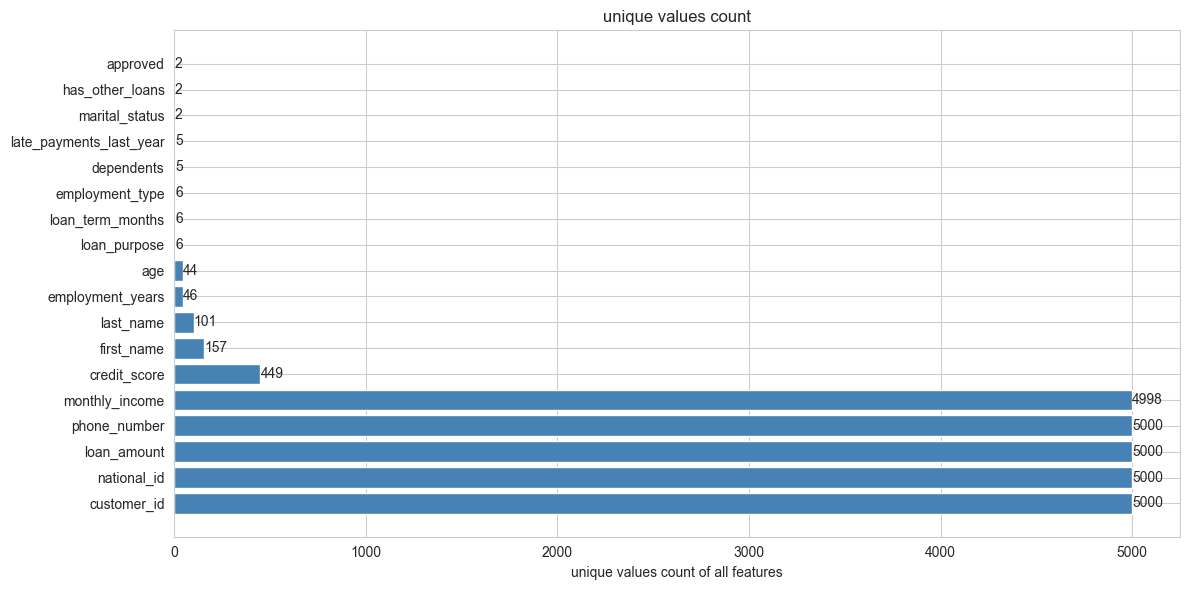

In [161]:
# محاسبه تعداد مقادیر متمایز هر ستون
distinct_counts = df.nunique().sort_values(ascending=False)

# رسم نمودار میله‌ای
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(distinct_counts)), distinct_counts.values, color="steelblue")

# تنظیمات
plt.yticks(range(len(distinct_counts)), distinct_counts.index)
plt.xlabel("unique values count of all features")
plt.title("unique values count")

# اضافه کردن اعداد روی میله‌ها
for i, v in enumerate(distinct_counts.values):
    plt.text(v + 1, i, str(v), va="center")

plt.tight_layout()
plt.show()

In [162]:
print("\n🔍 Missing Values:")
print("="* 50)
print(df.isnull().sum())


🔍 Missing Values:
customer_id                  0
first_name                   0
last_name                    0
national_id                  0
phone_number                 0
age                          0
marital_status               0
dependents                   0
employment_type              0
employment_years             0
monthly_income               0
credit_score               116
loan_amount                  0
loan_term_months             0
loan_purpose                 0
has_other_loans              0
late_payments_last_year      0
approved                     0
dtype: int64


In [163]:
print("\n📊 Target Distribution (approved):")
print(df["approved"].value_counts())


📊 Target Distribution (approved):
approved
1    3023
0    1977
Name: count, dtype: int64


In [164]:
print("\n🎯 Target Distribution (approved):")
target_dist = df["approved"].value_counts(normalize=True)
print(f"   Rejected (0): {target_dist[0] * 100:.1f}%")
print(f"   Approved (1): {target_dist[1] * 100:.1f}%")


🎯 Target Distribution (approved):
   Rejected (0): 39.5%
   Approved (1): 60.5%


C:\Users\My_Pc\AppData\Local\Temp\ipykernel_14040\2554852491.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dtype_counts, x="Data Type", y="Count", palette="viridis")


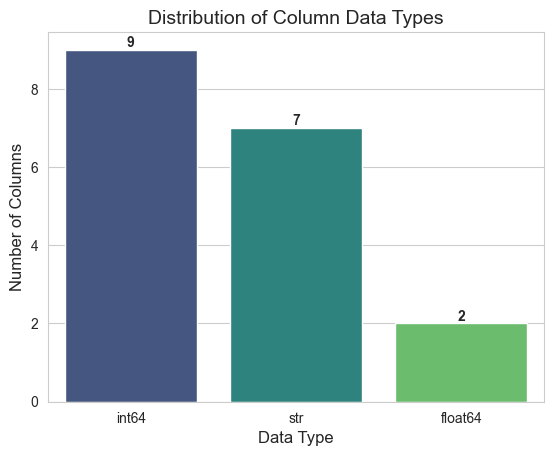

In [165]:
dtype_counts = df.dtypes.value_counts().reset_index()
dtype_counts.columns = ["Data Type", "Count"]

ax = sns.barplot(data=dtype_counts, x="Data Type", y="Count", palette="viridis")
plt.title("Distribution of Column Data Types", fontsize=14)
plt.xlabel("Data Type", fontsize=12)
plt.ylabel("Number of Columns", fontsize=12)

# This puts labels on all bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight="bold")

plt.show()

#### Data Cleaning

In [166]:
# Remove duplicates
before_dup = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before_dup - len(df)}")

# Handle missing values
print(f"\nMissing values before cleaning:")
print(df.isnull().sum())

Duplicates removed: 0

Missing values before cleaning:
customer_id                  0
first_name                   0
last_name                    0
national_id                  0
phone_number                 0
age                          0
marital_status               0
dependents                   0
employment_type              0
employment_years             0
monthly_income               0
credit_score               116
loan_amount                  0
loan_term_months             0
loan_purpose                 0
has_other_loans              0
late_payments_last_year      0
approved                     0
dtype: int64


In [167]:
median_score = df["credit_score"].median()
df["credit_score"] = df["credit_score"].fillna(median_score)
print(f"✅ credit_score filled with median: {median_score:.0f}")

print("\n✅ Data cleaning completed")

✅ credit_score filled with median: 723

✅ Data cleaning completed


#### Data Preprocessing

##### Encoding

In [168]:
print("\n" + "=" * 70)
print("Encoding Categorical Variables")
print("=" * 70)

df["marital_num"] = df["marital_status"].map({"مجرد": 0, "متأهل": 1})

le_employment = LabelEncoder()
df["employment_num"] = le_employment.fit_transform(df["employment_type"])

le_purpose = LabelEncoder()
df["purpose_num"] = le_purpose.fit_transform(df["loan_purpose"])

df = df.drop(columns=["marital_status", "employment_type", "loan_purpose"])

print("✅ Encoding completed")
print(f"   marital_status: Single=0, Married=1")
print(f"   employment_type: {dict(zip(le_employment.classes_, range(len(le_employment.classes_))))}")
print(f"   loan_purpose: {dict(zip(le_purpose.classes_, range(len(le_purpose.classes_))))}")



Encoding Categorical Variables
✅ Encoding completed
   marital_status: Single=0, Married=1
   employment_type: {'آزاد': 0, 'بازنشسته': 1, 'بیکار': 2, 'دولتی': 3, 'فریلنس': 4, 'کارمند': 5}
   loan_purpose: {'تحصیل': 0, 'خودرو': 1, 'شخصی': 2, 'مسکن': 3, 'پزشکی': 4, 'کسب_و_کار': 5}


In [169]:
df.head()

,customer_id,first_name,last_name,national_id,phone_number,age,dependents,employment_years,monthly_income,credit_score,loan_amount,loan_term_months,has_other_loans,late_payments_last_year,approved,marital_num,employment_num,purpose_num
0,1,نیایش,موحد,9697354961,09395310485,62,0,34.0,25945884,850.0,65425997,48,0,0,1,0,1,3
1,2,آیدا,رفیعی,1939042955,09642621108,23,0,0.0,22215582,643.0,100350425,48,1,0,0,0,4,0
2,3,حسين,علی شاهی,2193448329,09331191390,32,3,0.0,2921565,401.0,20699189,60,0,0,0,1,2,5
3,4,ياسين,ولاشجردی,2625792787,09692749116,24,1,0.0,12246988,554.0,38623712,12,0,1,0,1,5,3
4,5,ياسمين,قاضی,4721519026,09508157429,27,0,0.0,12260514,510.0,39933011,36,0,0,0,0,5,4


### 3- Featuer Engineering

Feature Selection

In [170]:
feature_columns = [
    "age",
    "dependents",
    "employment_years",
    "monthly_income",
    "credit_score",
    "loan_amount",
    "loan_term_months",
    "has_other_loans",
    "late_payments_last_year",
    "marital_num",
    "employment_num",
    "purpose_num",
]

X = df[feature_columns]
y = df["approved"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (5000, 12)
y shape: (5000,)


### 4- Model Training

Train-Test Split

In [171]:
print("\n" + "=" * 70)
print("Step 7: Train-Test Split")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")



Step 7: Train-Test Split
Training data: (4000, 12)
Test data: (1000, 12)


Train Model

In [172]:
print("\n" + "=" * 70)
print("Step 8: Train Decision Tree Model")
print("=" * 70)

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    class_weight="balanced",  # ← این خط را اضافه کنید
    random_state=42,
)

model.fit(X_train, y_train)
print("✅ Decision Tree model trained")



Step 8: Train Decision Tree Model
✅ Decision Tree model trained


### 5- Model Evaluation

##### Confusion Matrix

In [173]:
print("\n" + "=" * 70)
print("Step 9: Model Evaluation")
print("=" * 70)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Overall Accuracy: {accuracy * 100:.1f}%")

cm = confusion_matrix(y_test, y_pred)
print("\n📊 Confusion Matrix:")
print(f"                 Prediction")
print(f"              Reject  Approve")
print(f"Actual Reject  {cm[0, 0]:5d}   {cm[0, 1]:5d}")
print(f"Actual Approve {cm[1, 0]:5d}   {cm[1, 1]:5d}")

tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Detailed Performance:")
print(f"   Reject Class Accuracy: {tn / (tn + fp) * 100:.1f}%")
print(f"   Approve Class Accuracy: {tp / (tp + fn) * 100:.1f}%")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Reject", "Approve"]))



Step 9: Model Evaluation
🎯 Overall Accuracy: 82.8%

📊 Confusion Matrix:
                 Prediction
              Reject  Approve
Actual Reject    369      26
Actual Approve   146     459

📈 Detailed Performance:
   Reject Class Accuracy: 93.4%
   Approve Class Accuracy: 75.9%

📋 Classification Report:


              precision    recall  f1-score   support

      Reject       0.72      0.93      0.81       395
     Approve       0.95      0.76      0.84       605

    accuracy                           0.83      1000
   macro avg       0.83      0.85      0.83      1000
weighted avg       0.86      0.83      0.83      1000



### 6- Model Deployment

In [174]:
print("\n" + "=" * 70)
print("Step 12: Save Model")
print("=" * 70)

model_package = {
    "model": model,
    "employment_encoder": le_employment,
    "purpose_encoder": le_purpose,
    "features": feature_columns,
    "performance": {"accuracy": accuracy, "confusion_matrix": cm.tolist()},
}

joblib.dump(model_package, f"{ARTIFACT_FOLDER}/loan_model.pkl")
print("✅ Model saved: loan_model.pkl")



Step 12: Save Model
✅ Model saved: loan_model.pkl
